# Eksplorasi Data IDX Stock Summary

Notebook untuk melihat bentuk data mentah (panel) sampai fitur yang masuk ke Transformer.

Jalankan dari root repo (`E:\trading-BEI`) dengan venv aktif. Pastikan `data/processed/panel.parquet` sudah dibuat via `scraper.build_panel`.

## 1. Setup & load panel

Cell pertama pindah ke root repo supaya path `data/...` dan `import src...` bekerja walau notebook dijalankan dari folder `notebooks/`.

In [1]:
import os, sys
# pindah ke root repo (parent dari notebooks/) bila perlu
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
sys.path.insert(0, os.getcwd())
print('cwd:', os.getcwd())
assert os.path.exists('data/processed/panel.parquet'), 'panel belum ada - jalankan scraper.build_panel dulu'
print('panel found OK')

cwd: e:\trading-BEI
panel found OK


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 160)

PANEL = 'data/processed/panel.parquet'
panel = pd.read_parquet(PANEL)
print('shape:', panel.shape)
print('date range:', panel['date'].min().date(), '->', panel['date'].max().date())
print('n tickers:', panel['ticker'].nunique())
print('n trading days:', panel['date'].nunique())
panel.head()

shape: (959383, 19)
date range: 2022-01-03 -> 2026-07-02
n tickers: 973
n trading days: 1072


,date,ticker,name,prev_close,open,high,low,close,change,volume,value,frequency,foreign_buy,foreign_sell,listed_shares,tradeable_shares,bid,offer,remarks
0,2022-01-03,AALI,Astra Agro Lestari Tbk.,9500.0,0.0,9700.0,9500.0,9575.0,75.0,839600.0,8.055040e+09,637.0,123100.0,10600.0,1.924688e+09,1.924688e+09,9575.0,9600.0,--M-1M3PM00000D232------------
1,2022-01-03,ABBA,Mahaka Media Tbk.,354.0,0.0,356.0,330.0,330.0,-24.0,14000300.0,4.668460e+09,1342.0,320600.0,434900.0,2.755125e+09,2.755125e+09,0.0,330.0,--U-2105000000E614---L--------
2,2022-01-03,ABDA,Asuransi Bina Dana Arta Tbk.,5850.0,0.0,0.0,0.0,5850.0,0.0,0.0,0.000000e+00,0.0,0.0,0.0,6.208067e+08,6.208067e+08,5925.0,6700.0,--U-2105000000G412------------
3,2022-01-03,ABMM,ABM Investama Tbk.,1420.0,0.0,1405.0,1330.0,1400.0,-20.0,8463600.0,1.167041e+10,1673.0,830500.0,1994500.0,2.753165e+09,2.753165e+09,1395.0,1400.0,--M-1105000000C311------------
4,2022-01-03,ACES,Ace Hardware Indonesia Tbk.,1280.0,1285.0,1385.0,1285.0,1380.0,100.0,27012200.0,3.650076e+10,5371.0,17134500.0,4844800.0,1.715000e+10,1.715000e+10,1375.0,1380.0,--MO1H3EMN6000E743------------


## 2. Struktur & tipe kolom

In [3]:
panel.dtypes.to_frame('dtype')

,dtype
date,datetime64[us]
ticker,str
name,str
prev_close,float64
open,float64
high,float64
low,float64
close,float64
change,float64
volume,float64


In [4]:
# Statistik ringkas kolom numerik
panel[['open','high','low','close','volume','value','foreign_buy','foreign_sell']].describe().T

,count,mean,std,min,25%,50%,75%,max
open,959383.0,4.586302e+02,3.331104e+03,0.0,0.0,0.0,5.000000e+01,3.599250e+05
high,959383.0,1.197664e+03,5.594879e+03,0.0,67.0,222.0,8.050000e+02,3.980000e+05
low,959383.0,1.154358e+03,5.405263e+03,0.0,63.0,210.0,7.700000e+02,3.468250e+05
close,959383.0,1.361760e+03,5.991067e+03,1.0,89.0,256.0,8.850000e+02,3.599000e+05
volume,959383.0,2.469892e+07,2.228062e+08,0.0,26300.0,766400.0,7.776200e+06,4.594176e+10
value,959383.0,1.409162e+10,8.733655e+10,0.0,9031400.0,180514000.0,2.510158e+09,9.804286e+12
foreign_buy,959383.0,4.493793e+06,8.531092e+07,0.0,0.0,0.0,3.478000e+05,4.223009e+10
foreign_sell,959383.0,4.734907e+06,8.122660e+07,0.0,0.0,200.0,4.013000e+05,2.691289e+10


## 3. Coverage: jumlah saham per hari & hari bursa per tahun

rata-rata saham/hari: 894.9

hari bursa per tahun:
date
2022    246
2023    239
2024    237
2025    236
2026    114
Name: date, dtype: int64


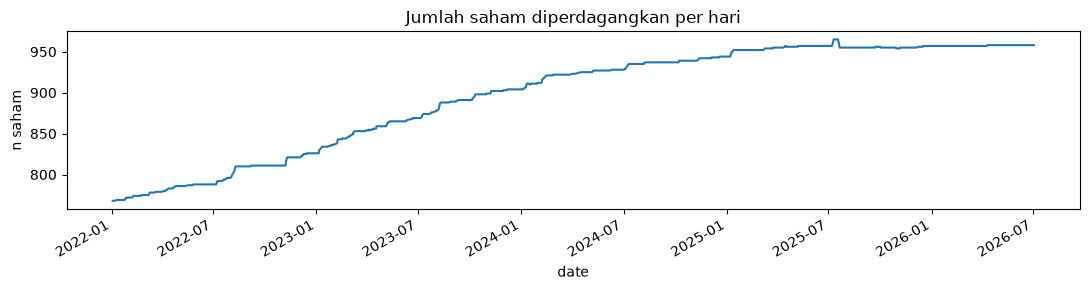

In [5]:
per_day = panel.groupby('date')['ticker'].nunique()
print('rata-rata saham/hari:', round(per_day.mean(),1))
per_year = panel.groupby(panel['date'].dt.year)['date'].nunique()
print('\nhari bursa per tahun:')
print(per_year)

fig, ax = plt.subplots(figsize=(11,3))
per_day.plot(ax=ax)
ax.set_title('Jumlah saham diperdagangkan per hari')
ax.set_ylabel('n saham'); plt.tight_layout(); plt.show()

## 4. Kualitas data: missing & volume nol

In [6]:
print('null per kolom:')
print(panel.isna().sum())
zero_vol = (panel['volume']==0).mean()*100
print(f'\nbaris volume nol: {zero_vol:.1f}%  (saham tidak likuid / suspend)')
# berapa hari per ticker (deteksi delisting / listing baru)
days_per_ticker = panel.groupby('ticker')['date'].nunique().sort_values()
print('\nticker dengan riwayat terpendek (kemungkinan IPO baru / delisting):')
print(days_per_ticker.head(8))

null per kolom:
date                0
ticker              0
name                0
prev_close          0
open                0
high                0
low                 0
close               0
change              0
volume              0
value               0
frequency           0
foreign_buy         0
foreign_sell        0
listed_shares       0
tradeable_shares    0
bid                 0
offer               0
remarks             0
dtype: int64

baris volume nol: 11.1%  (saham tidak likuid / suspend)

ticker dengan riwayat terpendek (kemungkinan IPO baru / delisting):
ticker
WBSA     53
SUPA    122
RLCO    129
PJHB    151
EMAS    183
MERI    234
PMUI    234
BLOG    234
Name: date, dtype: int64


## 5. Lihat satu saham (contoh: BBCA)

(1072, 19)


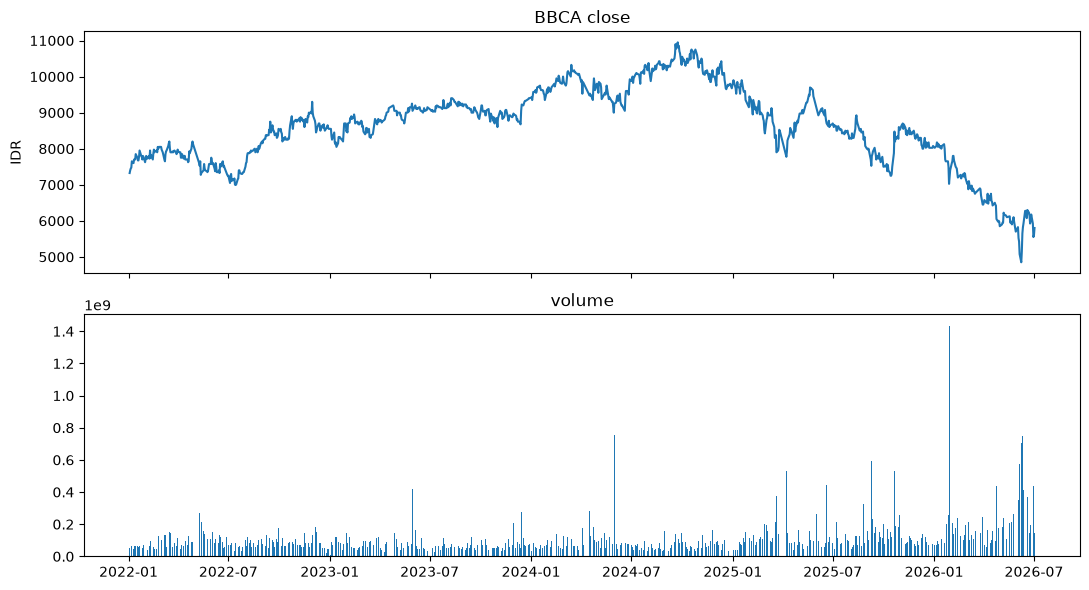

,date,ticker,name,prev_close,open,high,low,close,change,volume,value,frequency,foreign_buy,foreign_sell,listed_shares,tradeable_shares,bid,offer,remarks
954689,2026-06-26,BBCA,Bank Central Asia Tbk.,6025.0,6050.0,6175.0,6025.0,6175.0,150.0,163378700.0,9.985355e+11,32338.0,136562700.0,66299200.0,1.220423e+11,1.220423e+11,6150.0,6175.0,XDMO1UQNCNU600G111------------
955647,2026-06-29,BBCA,Bank Central Asia Tbk.,6175.0,6175.0,6200.0,5925.0,5925.0,-250.0,189886600.0,1.145710e+12,46637.0,93315300.0,163734800.0,1.220423e+11,1.220423e+11,5925.0,5950.0,XDMO1UQNCNU600G111------------
956605,2026-06-30,BBCA,Bank Central Asia Tbk.,5925.0,5775.0,5825.0,5550.0,5550.0,-375.0,440738300.0,2.500652e+12,87107.0,199781600.0,335110400.0,1.220423e+11,1.220423e+11,5550.0,5600.0,XDMO1UQNCNU600G111------------
957563,2026-07-01,BBCA,Bank Central Asia Tbk.,5550.0,5550.0,5750.0,5550.0,5600.0,50.0,124123800.0,7.028525e+11,32186.0,65212600.0,41323200.0,1.220423e+11,1.220423e+11,5600.0,5625.0,XDMO1UQNCNU600G111------------
958521,2026-07-02,BBCA,Bank Central Asia Tbk.,5600.0,5650.0,5875.0,5625.0,5800.0,200.0,145119400.0,8.414377e+11,31197.0,108510700.0,83784100.0,1.220423e+11,1.220423e+11,5800.0,5825.0,XDMO1UQNCNU600G111------------


In [7]:
TICK = 'BBCA'  # ganti sesuai selera, mis. 'BBRI','TLKM','GOTO'
one = panel[panel['ticker']==TICK].sort_values('date')
print(one.shape)
fig, ax = plt.subplots(2,1, figsize=(11,6), sharex=True)
ax[0].plot(one['date'], one['close']); ax[0].set_title(f'{TICK} close'); ax[0].set_ylabel('IDR')
ax[1].bar(one['date'], one['volume']); ax[1].set_title('volume'); 
plt.tight_layout(); plt.show()
one.tail()

## 6. Distribusi return harian

mean: -0.00026 | std: 0.03777 | skew: 1.101


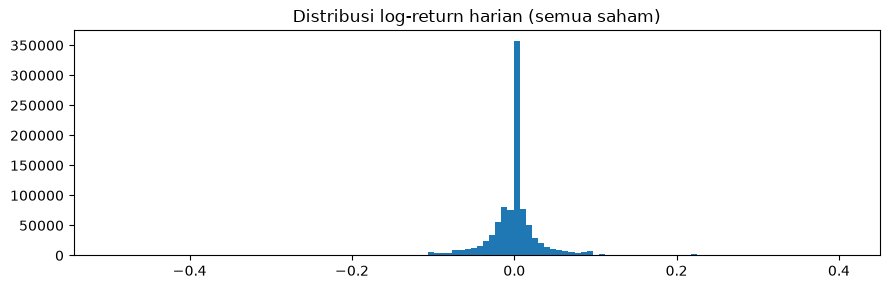

In [8]:
tmp = panel.sort_values(['ticker','date']).copy()
tmp['ret'] = np.log(tmp['close'] / tmp.groupby('ticker')['close'].shift(1))
r = tmp['ret'].replace([np.inf,-np.inf], np.nan).dropna()
r = r[r.abs() < 0.5]  # buang outlier ekstrem utk plot
print('mean:', round(r.mean(),5), '| std:', round(r.std(),5), '| skew:', round(r.skew(),3))
fig, ax = plt.subplots(figsize=(9,3))
ax.hist(r, bins=120); ax.set_title('Distribusi log-return harian (semua saham)')
plt.tight_layout(); plt.show()

## 7. Fitur yang masuk ke model (preprocess + normalize)

In [9]:
from src.preprocess import compute_features, normalize, FEATURE_COLUMNS, TARGET_COLUMN
feats = normalize(compute_features(panel, horizon=1))
print('feature rows:', feats.shape)
print('feature cols:', FEATURE_COLUMNS)
feats.head()

e:\trading-BEI\.venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


feature rows: (240575, 10)
feature cols: ['log_return', 'overnight_return', 'hl_range', 'log_volume', 'log_value', 'turnover', 'foreign_flow_ratio']


,date,ticker,log_return,overnight_return,hl_range,log_volume,log_value,turnover,foreign_flow_ratio,fwd_return
0,2024-12-09,AADI,4.629099,5.000000,-0.928063,1.189577,2.193090,0.126873,-0.499419,0.073173
1,2024-12-10,AADI,2.367783,5.000000,3.098137,1.820460,2.724932,2.677726,-0.333627,-0.067951
2,2024-12-11,AADI,-2.585755,-0.156913,1.415084,1.473356,2.387940,0.757027,-0.663518,-0.042560
3,2024-12-12,AADI,-1.323705,-0.830995,0.870499,1.396569,2.312380,0.452566,-0.550940,0.000000
4,2024-12-13,AADI,0.228427,-0.048991,-0.033272,1.162002,2.152534,0.325263,-0.223374,0.005420


In [10]:
# Cek normalisasi cross-sectional: per hari mean~0, std~1
d = feats['date'].iloc[len(feats)//2]
day = feats[feats['date']==d][FEATURE_COLUMNS]
print('tanggal:', pd.Timestamp(d).date(), '| n saham:', len(day))
pd.DataFrame({'mean':day.mean().round(4), 'std':day.std(ddof=0).round(4)})

tanggal: 2025-10-22 | n saham: 595


,mean,std
log_return,0.0118,0.8936
overnight_return,0.0155,0.7169
hl_range,-0.0000,1.0000
log_volume,-0.0000,1.0000
log_value,0.0000,1.0000
turnover,-0.0274,0.7814
foreign_flow_ratio,0.0013,0.9930


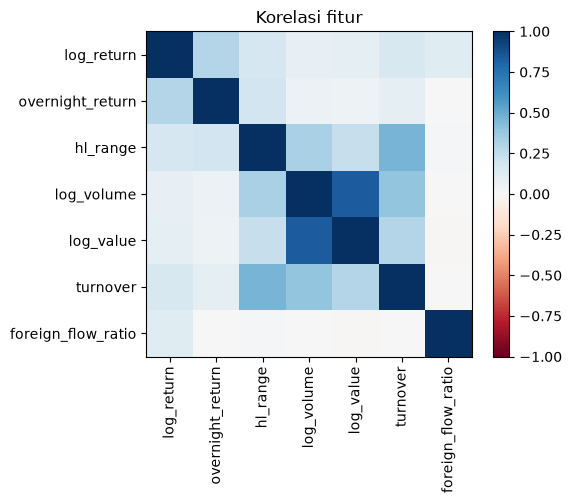

In [11]:
# Korelasi antar fitur
import numpy as np
corr = feats[FEATURE_COLUMNS].corr()
fig, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(corr, cmap='RdBu', vmin=-1, vmax=1)
ax.set_xticks(range(len(FEATURE_COLUMNS))); ax.set_xticklabels(FEATURE_COLUMNS, rotation=90)
ax.set_yticks(range(len(FEATURE_COLUMNS))); ax.set_yticklabels(FEATURE_COLUMNS)
fig.colorbar(im); ax.set_title('Korelasi fitur'); plt.tight_layout(); plt.show()

## 8. Bentuk input Transformer (satu window)

jumlah sample: 194232
x shape (lookback, n_features): (60, 7)
target fwd_return: -0.011472401209175587
meta: AADI 2025-03-11


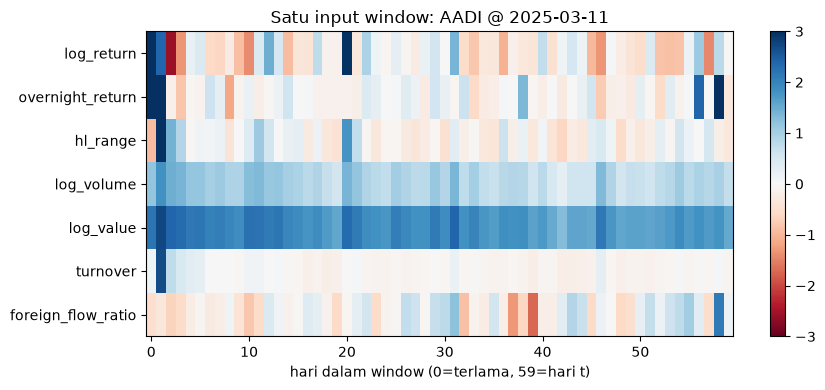

In [12]:
from src.dataset import IDXWindowDataset
ds = IDXWindowDataset(feats, lookback=60)
print('jumlah sample:', len(ds))
x, y, meta = ds[0]
x = np.asarray(x)
print('x shape (lookback, n_features):', x.shape)
print('target fwd_return:', float(y))
print('meta:', meta['ticker'], str(meta['date'].date()))

fig, ax = plt.subplots(figsize=(9,4))
im = ax.imshow(x.T, aspect='auto', cmap='RdBu', vmin=-3, vmax=3)
ax.set_yticks(range(len(FEATURE_COLUMNS))); ax.set_yticklabels(FEATURE_COLUMNS)
ax.set_xlabel('hari dalam window (0=terlama, 59=hari t)')
ax.set_title(f'Satu input window: {meta["ticker"]} @ {meta["date"].date()}')
fig.colorbar(im); plt.tight_layout(); plt.show()

## Ringkasan bentuk data

- **Panel** (long): satu baris = satu (tanggal, saham), kolom OHLC + volume/value + foreign flow.
- **Fitur**: 7 fitur kausal ternormalisasi cross-sectional per hari.
- **Input model**: tensor `(lookback=60, n_features=7)` per (saham, hari), target = return besok.
